# FX8 Minimodel Discovery Playground

This notebook is a small interactive harness around `projects.minimodel_discovery.spec`.
It is meant for quick iteration on the fixed Gabor bank, anchor-cell diagnostics, and the two analytic seed models before running full discovery.

In [3]:
from __future__ import annotations

import os
import sys
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import Image as IPyImage, display

# Ensure repo root (the folder that contains /projects and /src) is importable
_CWD = Path.cwd().resolve()
REPO_ROOT = None
for p in (_CWD, *_CWD.parents):
    if (p / "projects").exists() and (p / "src").exists():
        REPO_ROOT = p
        break

if REPO_ROOT is None:
    raise RuntimeError("Could not locate repository root containing 'projects' and 'src'.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

USE_CPU_FOR_NOTEBOOK = True
if USE_CPU_FOR_NOTEBOOK and "JAX_PLATFORM_NAME" not in os.environ:
    os.environ["JAX_PLATFORM_NAME"] = "cpu"

from projects.minimodel_discovery import spec
from projects.minimodel_discovery.primitives import make_gabor_kernels
from src import utils
from src.hypothesis_engine import objective

PROJECT_DIR = REPO_ROOT / "projects" / "minimodel_discovery"
CONFIG_PATH = PROJECT_DIR / "config.yaml"
OUTPUT_DIR = PROJECT_DIR / "playground_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

SEEDS = {
    "seed_v1": {
        "model": spec.model_v1,
        "param_estimator": spec.param_est_v1,
    },
    "seed_v2": {
        "model": spec.model_v2,
        "param_estimator": spec.param_est_v2,
    },
}


In [4]:
def load_config(config_path=CONFIG_PATH):
    with open(config_path, "r", encoding="utf-8") as handle:
        return yaml.safe_load(handle) or {}


def _coerce_index_array(values):
    return np.asarray(values).reshape(-1).astype(np.int64, copy=False)


def build_bundle(
    config_path=CONFIG_PATH,
    *,
    random_seed=0,
    max_cells=None,
    max_train_images=None,
    eval_image_count=None,
    use_teacher_diagnostics=None,
):
    config = load_config(config_path)
    data_kwargs = dict(config.get("data_processing_params", {}))
    if max_cells is not None:
        data_kwargs["max_cells"] = int(max_cells)
    if max_train_images is not None:
        data_kwargs["max_train_images"] = int(max_train_images)
    if use_teacher_diagnostics is not None:
        data_kwargs["use_teacher_diagnostics"] = bool(use_teacher_diagnostics)

    data = spec.load_and_process_data(**data_kwargs)
    n_samples = utils.data_n_samples(data)
    n_trials = utils.data_n_trials(data)

    train_samples, train_trials = spec.train_test_split(data, random_seed=random_seed)
    train_samples = _coerce_index_array(train_samples)
    train_trials = _coerce_index_array(train_trials)
    test_samples = np.setdiff1d(np.arange(n_samples, dtype=np.int64), train_samples, assume_unique=False)
    test_trials = np.setdiff1d(np.arange(n_trials, dtype=np.int64), train_trials, assume_unique=False)

    bundle = {
        "config": config,
        "data": data,
        "train_samples": train_samples,
        "test_samples": test_samples,
        "train_trials": train_trials,
        "test_trials": test_trials,
        "train_train": utils.slice_data_trials(utils.slice_data_samples(data, train_samples), train_trials),
        "train_test": utils.slice_data_trials(utils.slice_data_samples(data, train_samples), test_trials),
        "test_train": utils.slice_data_trials(utils.slice_data_samples(data, test_samples), train_trials),
        "test_test": utils.slice_data_trials(utils.slice_data_samples(data, test_samples), test_trials),
        "random_seed": int(random_seed),
    }

    experiment_params = config.get("experiment_params", {})
    n_eval_images = int(eval_image_count or experiment_params.get("eval_image_count", 64))
    eval_source = experiment_params.get("eval_image_source", "train_anchor")
    bundle["X_eval"] = spec.build_evaluation_points(
        bundle["train_train"],
        random_seed=random_seed,
        n_eval_images=n_eval_images,
        source=eval_source,
    )
    return bundle


def describe_bundle(bundle):
    rows = []
    for key in ("data", "train_train", "train_test", "test_train", "test_test", "X_eval"):
        data = bundle[key]
        rows.append(
            {
                "split": key,
                "n_cells": utils.data_n_samples(data),
                "n_trials": utils.data_n_trials(data),
                "image_shape": tuple(np.asarray(data["image"]).shape[1:3]),
            }
        )
    return pd.DataFrame(rows)


def plot_gabor_bank(figsize=(10, 6)):
    kernels = np.asarray(make_gabor_kernels())[:, 0]
    n_kernels = kernels.shape[0]
    n_cols = 4
    n_rows = int(np.ceil(n_kernels / n_cols))
    vmax = max(float(np.percentile(np.abs(kernels), 99)), 1e-4)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = np.asarray(axes).reshape(-1)
    for idx, ax in enumerate(axes):
        if idx < n_kernels:
            ax.imshow(kernels[idx], cmap="RdBu_r", vmin=-vmax, vmax=vmax)
            ax.set_title(f"filter {idx}", fontsize=9)
        else:
            ax.axis("off")
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle("Fixed 16-filter Gabor / quadrature bank", fontsize=13)
    fig.tight_layout(rect=[0.0, 0.0, 1.0, 0.95])
    return fig


def show_anchor_panels(bundle, data_key="train_train", max_rows=4, figsize=(14, 4)):
    cache = spec._build_anchor_cache(bundle[data_key])
    anchors = cache["anchors"][: max_rows]
    fig, axes = plt.subplots(len(anchors), 2, figsize=(figsize[0], figsize[1] * max(1, len(anchors))))
    axes = np.asarray(axes).reshape(len(anchors), 2)
    for row_idx, anchor in enumerate(anchors):
        axes[row_idx, 0].imshow(anchor["summary_panel"])
        axes[row_idx, 0].set_title(f"cell {anchor['cell_id']} static summary", fontsize=10)
        axes[row_idx, 1].imshow(anchor["teacher_panel"])
        axes[row_idx, 1].set_title(f"cell {anchor['cell_id']} teacher panel", fontsize=10)
        for ax in axes[row_idx]:
            ax.set_xticks([])
            ax.set_yticks([])
    fig.tight_layout()
    return fig


def per_sample_poisson_losses(model_fn, params, data):
    n_samples = utils.data_n_samples(data)
    params_batched = utils.broadcast_params(params, n_samples)
    losses = []
    for sample_idx in range(n_samples):
        sample = utils.get_data_sample(data, sample_idx)
        sample_params = utils.slice_params(params_batched, sample_idx)
        pred = utils.call_model(model_fn, sample, sample_params, prefer_jax=False)
        raw_loss = np.asarray(spec.loss_fn(pred, sample), dtype=np.float32)
        losses.append(float(np.mean(raw_loss)))
    return np.asarray(losses, dtype=np.float32)


def summarize_program(bundle, program, data_key="train_test"):
    data = bundle[data_key]
    n_samples = utils.data_n_samples(data)
    params_batched = utils.broadcast_params(program["params"], n_samples)
    rows = []
    for sample_idx in range(n_samples):
        sample = utils.get_data_sample(data, sample_idx)
        sample_params = utils.slice_params(params_batched, sample_idx)
        pred = np.asarray(utils.call_model(program["model"], sample, sample_params, prefer_jax=False), dtype=np.float32).reshape(-1)
        fev, feve = spec._feve_for_sample(sample["response_repeats"], pred)
        rows.append(
            {
                "label": program["label"],
                "sample_idx": sample_idx,
                "cell_id": int(np.asarray(sample["cell_index"]).reshape(-1)[0]),
                "loss": float(program["losses"][sample_idx]),
                "fev": fev,
                "feve": feve,
                "response_std": float(np.std(np.asarray(sample["response"], dtype=np.float32))),
                "pred_std": float(np.std(pred)),
            }
        )
    return pd.DataFrame(rows)


def build_seed_program(
    bundle,
    seed_name,
    *,
    fit=False,
    fit_train_key="train_train",
    fit_test_key="train_test",
    score_data_key="train_test",
    max_iter=60,
    learning_rate=0.03,
    trial_batch_size=128,
):
    seed = SEEDS[seed_name]
    model_fn = seed["model"]
    param_estimator = seed["param_estimator"]

    if fit:
        t0 = time.time()
        initial_loss, initial_params, final_loss, fitted_params = objective(
            model=model_fn,
            param_estimator=param_estimator,
            data=[bundle[fit_train_key], bundle[fit_test_key]],
            loss_fn=spec.loss_fn,
            param_penalty_weight=0.0,
            fit_params=True,
            max_iter=max_iter,
            learning_rate=learning_rate,
            use_param_estimator=True,
            trial_batch_size=trial_batch_size,
        )
        params = fitted_params
        fit_summary = {
            "initial_loss": float(initial_loss),
            "final_loss": float(final_loss),
            "fit_time_s": time.time() - t0,
        }
    else:
        params = utils.stack_params(
            [
                param_estimator(utils.get_data_sample(bundle[fit_train_key], idx))
                for idx in range(utils.data_n_samples(bundle[fit_train_key]))
            ]
        )
        initial_losses = per_sample_poisson_losses(model_fn, params, bundle[fit_train_key])
        fit_summary = {
            "initial_loss": float(np.mean(initial_losses)),
            "final_loss": float(np.mean(initial_losses)),
            "fit_time_s": 0.0,
        }

    score_losses = per_sample_poisson_losses(model_fn, params, bundle[score_data_key])
    program = {
        "label": seed_name if not fit else f"{seed_name}_fit",
        "model": model_fn,
        "param_estimator": param_estimator,
        "params": params,
        "losses": score_losses,
        "fit_summary": fit_summary,
    }
    return program


def build_seed_programs(bundle, seeds=("seed_v1", "seed_v2"), **kwargs):
    programs = [build_seed_program(bundle, seed_name, **kwargs) for seed_name in seeds]
    summary_rows = []
    for program in programs:
        table = summarize_program(bundle, program)
        summary_rows.append(
            {
                "label": program["label"],
                "mean_loss": float(table["loss"].mean()),
                "mean_feve": float(table["feve"].mean(skipna=True)),
                "median_feve": float(table["feve"].median(skipna=True)),
                "fit_time_s": float(program["fit_summary"]["fit_time_s"]),
                "initial_loss": float(program["fit_summary"]["initial_loss"]),
                "final_loss": float(program["fit_summary"]["final_loss"]),
            }
        )
    return programs, pd.DataFrame(summary_rows)


def render_seed_diagnostics(
    bundle,
    programs,
    *,
    data_key="train_test",
    eval_key="X_eval",
    out_name="seed_diagnostics.png",
    title_prefix="seed playground",
):
    out_path = OUTPUT_DIR / out_name
    labels = [program["label"] for program in programs]
    programs_list = [
        {
            "model": program["model"],
            "params": program["params"],
            "losses": program["losses"],
        }
        for program in programs
    ]
    spec.plot_model_fits(
        data=bundle[data_key],
        programs_list=programs_list,
        X_eval=bundle[eval_key],
        save_path=str(out_path),
        labels=labels,
        title_prefix=title_prefix,
    )
    display(IPyImage(filename=str(out_path)))
    return out_path


def inspect_program_cell(bundle, program, sample_idx=0, data_key="train_test"):
    data = bundle[data_key]
    sample = utils.get_data_sample(data, sample_idx)
    params = utils.slice_params(utils.broadcast_params(program["params"], utils.data_n_samples(data)), sample_idx)
    pred = np.asarray(utils.call_model(program["model"], sample, params, prefer_jax=False), dtype=np.float32).reshape(-1)
    obs = np.asarray(sample["response"], dtype=np.float32).reshape(-1)
    order = np.argsort(obs)[::-1]
    fev, feve = spec._feve_for_sample(sample["response_repeats"], pred)
    cell_id = int(np.asarray(sample["cell_index"]).reshape(-1)[0])
    top_idx = np.argsort(pred)[-4:][::-1]
    top_images = np.transpose(np.asarray(sample["image"], dtype=np.float32)[..., top_idx], (2, 0, 1))
    vmax = max(float(np.percentile(np.abs(top_images), 99)), 1e-4)

    fig, axes = plt.subplots(2, 4, figsize=(12, 5))
    for col_idx in range(4):
        axes[0, col_idx].imshow(top_images[col_idx], cmap="gray", vmin=-vmax, vmax=vmax)
        axes[0, col_idx].set_title(f"top pred {col_idx + 1}", fontsize=9)
        axes[0, col_idx].set_xticks([])
        axes[0, col_idx].set_yticks([])
    axes[1, 0].plot(obs[order], color="black", lw=1.7, label="observed")
    axes[1, 0].plot(pred[order], color="#4C78A8", lw=1.7, label="predicted")
    axes[1, 0].legend(frameon=False, fontsize=8)
    axes[1, 0].set_title(f"{program['label']} | cell {cell_id}", fontsize=10)
    axes[1, 0].set_xlabel("trials sorted by observed response")
    axes[1, 0].set_ylabel("response")
    axes[1, 1].hist(obs - pred, bins=20, color="#E45756", alpha=0.9)
    axes[1, 1].set_title("residuals", fontsize=10)
    axes[1, 2].scatter(obs, pred, s=12, alpha=0.6, color="#54A24B")
    axes[1, 2].set_title("observed vs predicted", fontsize=10)
    axes[1, 2].set_xlabel("observed")
    axes[1, 2].set_ylabel("predicted")
    axes[1, 3].axis("off")
    axes[1, 3].text(
        0.0,
        1.0,
        "\n".join(
            [
                f"cell_id: {cell_id}",
                f"loss: {program['losses'][sample_idx]:.3f}",
                f"FEV: {fev:.3f}",
                f"FEVE: {feve:.3f}",
                f"obs std: {np.std(obs):.3f}",
                f"pred std: {np.std(pred):.3f}",
            ]
        ),
        va="top",
        ha="left",
        fontsize=10,
    )
    fig.tight_layout()
    return fig


In [5]:
RANDOM_SEED = 0
MAX_CELLS = 4
MAX_TRAIN_IMAGES = 64
EVAL_IMAGE_COUNT = 24
USE_TEACHER_DIAGNOSTICS = False

bundle = build_bundle(
    random_seed=RANDOM_SEED,
    max_cells=MAX_CELLS,
    max_train_images=MAX_TRAIN_IMAGES,
    eval_image_count=EVAL_IMAGE_COUNT,
    use_teacher_diagnostics=USE_TEACHER_DIAGNOSTICS,
)

describe_bundle(bundle)


,split,n_cells,n_trials,image_shape
0,data,4,564,"(66, 130)"
1,train_train,2,64,"(66, 130)"
2,train_test,2,500,"(66, 130)"
3,test_train,2,64,"(66, 130)"
4,test_test,2,500,"(66, 130)"
5,X_eval,2,24,"(66, 130)"


In [ ]:
plot_gabor_bank();
show_anchor_panels(bundle, data_key="train_train", max_rows=4);


INFO:2026-04-13 13:40:32,841:jax._src.xla_bridge:749: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2026-04-13 13:40:32 | INFO | 219357ms | Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


In [7]:
seed_programs, seed_summary = build_seed_programs(
    bundle,
    fit=False,
    score_data_key="train_test",
)
seed_summary


,label,mean_loss,mean_feve,median_feve,fit_time_s,initial_loss,final_loss
0,seed_v1,2.707087,-20.732918,-20.732918,0.0,2.730926,2.730926
1,seed_v2,1.597846,-0.286806,-0.286806,0.0,1.205367,1.205367


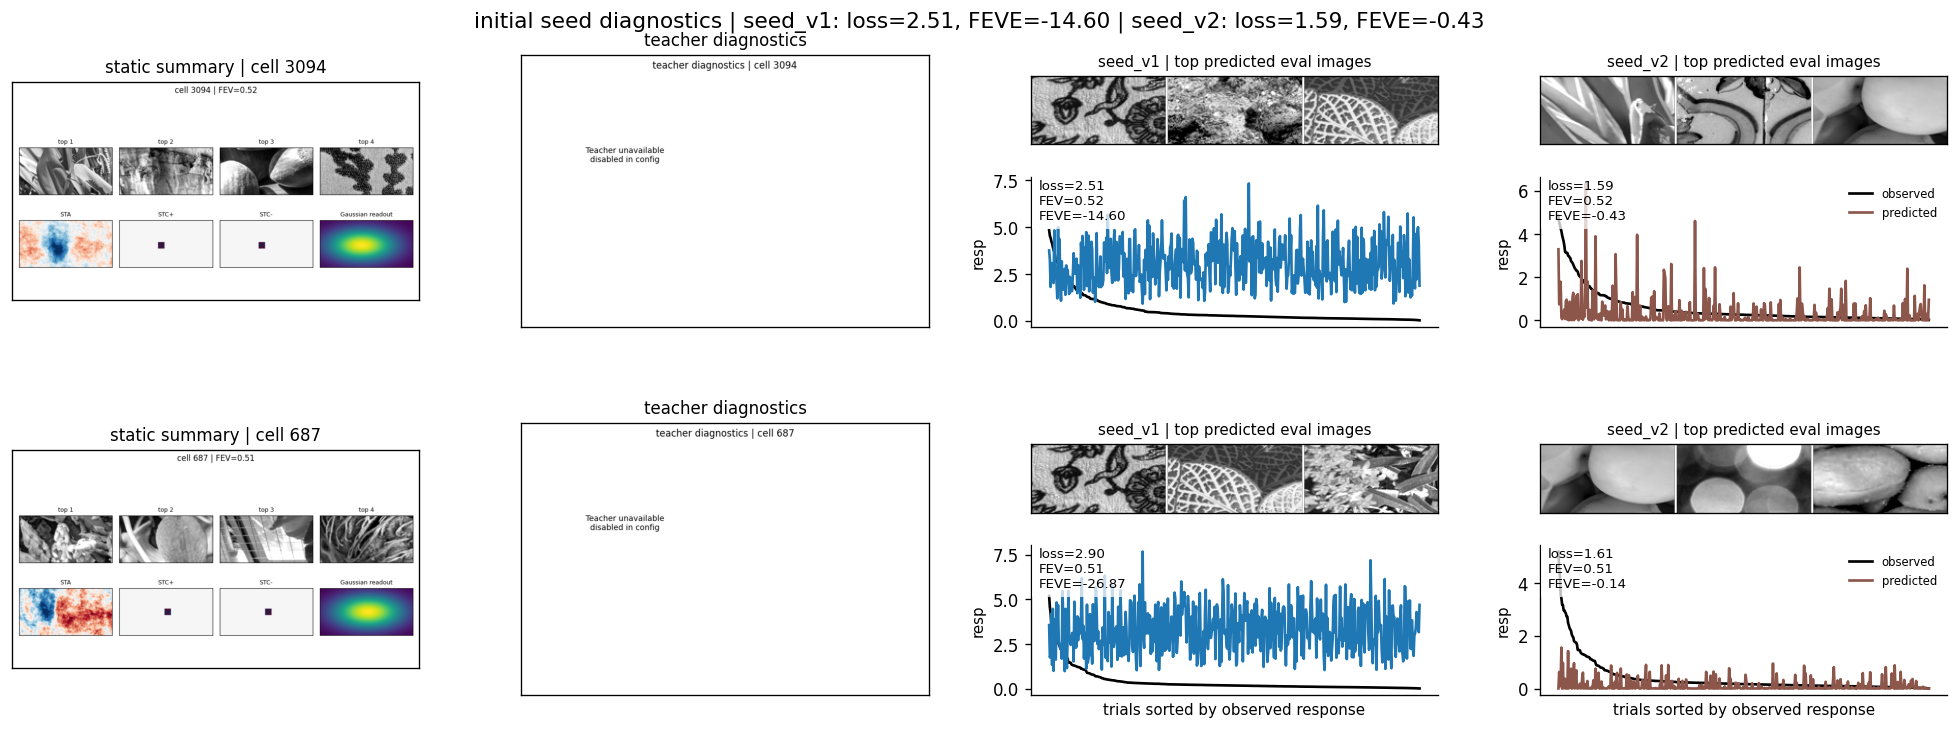

PosixPath('/home/reilly/Documents/code/EDGAR/projects/minimodel_discovery/playground_outputs/seed_diagnostics_initial.png')

In [8]:
render_seed_diagnostics(
    bundle,
    seed_programs,
    data_key="train_test",
    out_name="seed_diagnostics_initial.png",
    title_prefix="initial seed diagnostics",
)


In [ ]:
fitted_programs, fitted_summary = build_seed_programs(
    bundle,
    fit=True,
    score_data_key="train_test",
    max_iter=40,
    learning_rate=0.03,
    trial_batch_size=32,
)
fitted_summary


In [ ]:
render_seed_diagnostics(
    bundle,
    fitted_programs,
    data_key="train_test",
    out_name="seed_diagnostics_fitted.png",
    title_prefix="fitted seed diagnostics",
)


In [ ]:
# Pick any cell index from 0 to len(bundle["train_samples"]) - 1.
CELL_TO_INSPECT = 0

inspect_program_cell(bundle, fitted_programs[0], sample_idx=CELL_TO_INSPECT, data_key="train_test");
summarize_program(bundle, fitted_programs[0]).sort_values("feve", ascending=False).head(10)
